**Data Cleaning and Processing**

EPIC - RL2 - SP3

Paulo Yoshio Kuga

In [8]:
import lissa as li
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt

In [2]:
baseData = li.DataPreparer("../data","full_sensor_1h [old].csv")
entireData,pumpList = li.FailureMerge(baseData,"../data","respostas.csv")
entireData = li.FeatureCreation(entireData)
totalData = li.ProcessData(pumpList,entireData,totalDataPath="../data/totalProcessedData.csv")

número de bombas: 38
número de runs: 57


/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/processing.py:234: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  totalData = pd.concat([totalData,
/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/processing.py:234: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  totalData = pd.concat([totalData,


In [21]:
baseDataHeaders = [
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'ESP motor Current - phase A',
    'ESP motor Current - phase B',
    'ESP motor Current - phase C',
    'ESP Vibration X',
    'ESP Vibration Y'
    ]


Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'Current Mean',
    'ESP Vibration X',
    'ESP Vibration Y'
    #'ESP Power'
    ]

<Axes: >

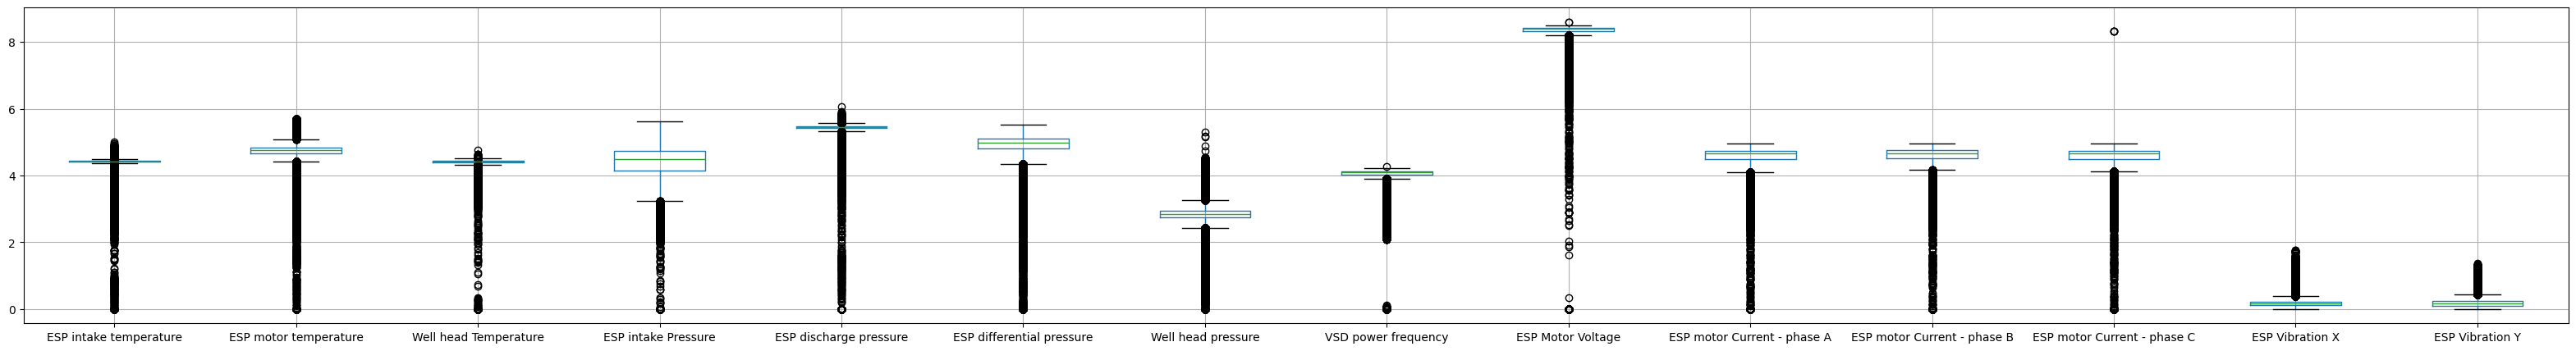

In [19]:
boxplot_data = baseData.loc[baseData["Well_down"]==0][baseDataHeaders].copy().fillna(0)
#boxplot_data["ESP Motor Voltage"] = boxplot_data["ESP Motor Voltage"]/1000
pd.plotting.boxplot(boxplot_data.apply(np.log1p),figsize=(40,5))

In [22]:
baseData.loc[baseData["Well_down"]==0][baseDataHeaders].hist(bins=50,figsize=(15,10))
plt.suptitle("Original Data Histograms",fontsize=20)
plt.tight_layout(pad=1.3)
plt.savefig("../imagens_gerais/hist_original.jpg")

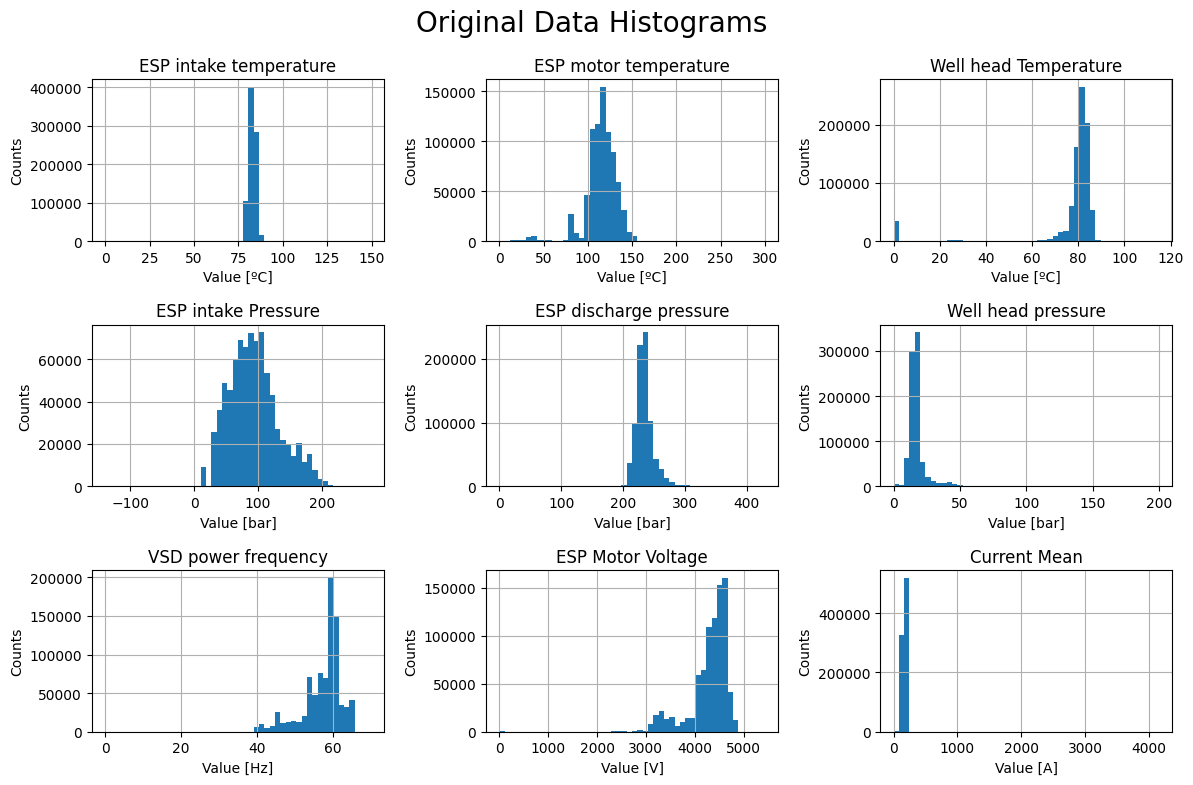

In [28]:
axes = entireData.loc[entireData["Well_down"]==0][Headers].hist(bins=50,figsize=(12,8))

i = 0
measures = ["ºC","ºC","ºC","bar","bar","bar","Hz","V","A"]

for ax in axes.flatten():
    ax.set_xlabel("Value [" +measures[i]+"]" )  # Define a legenda com o nome da coluna
    ax.set_ylabel("Counts")

    i += 1


plt.suptitle("Original Data Histograms",fontsize=20)
plt.tight_layout(pad=1.3)
plt.savefig("../imagens_gerais/hist_original.jpg")

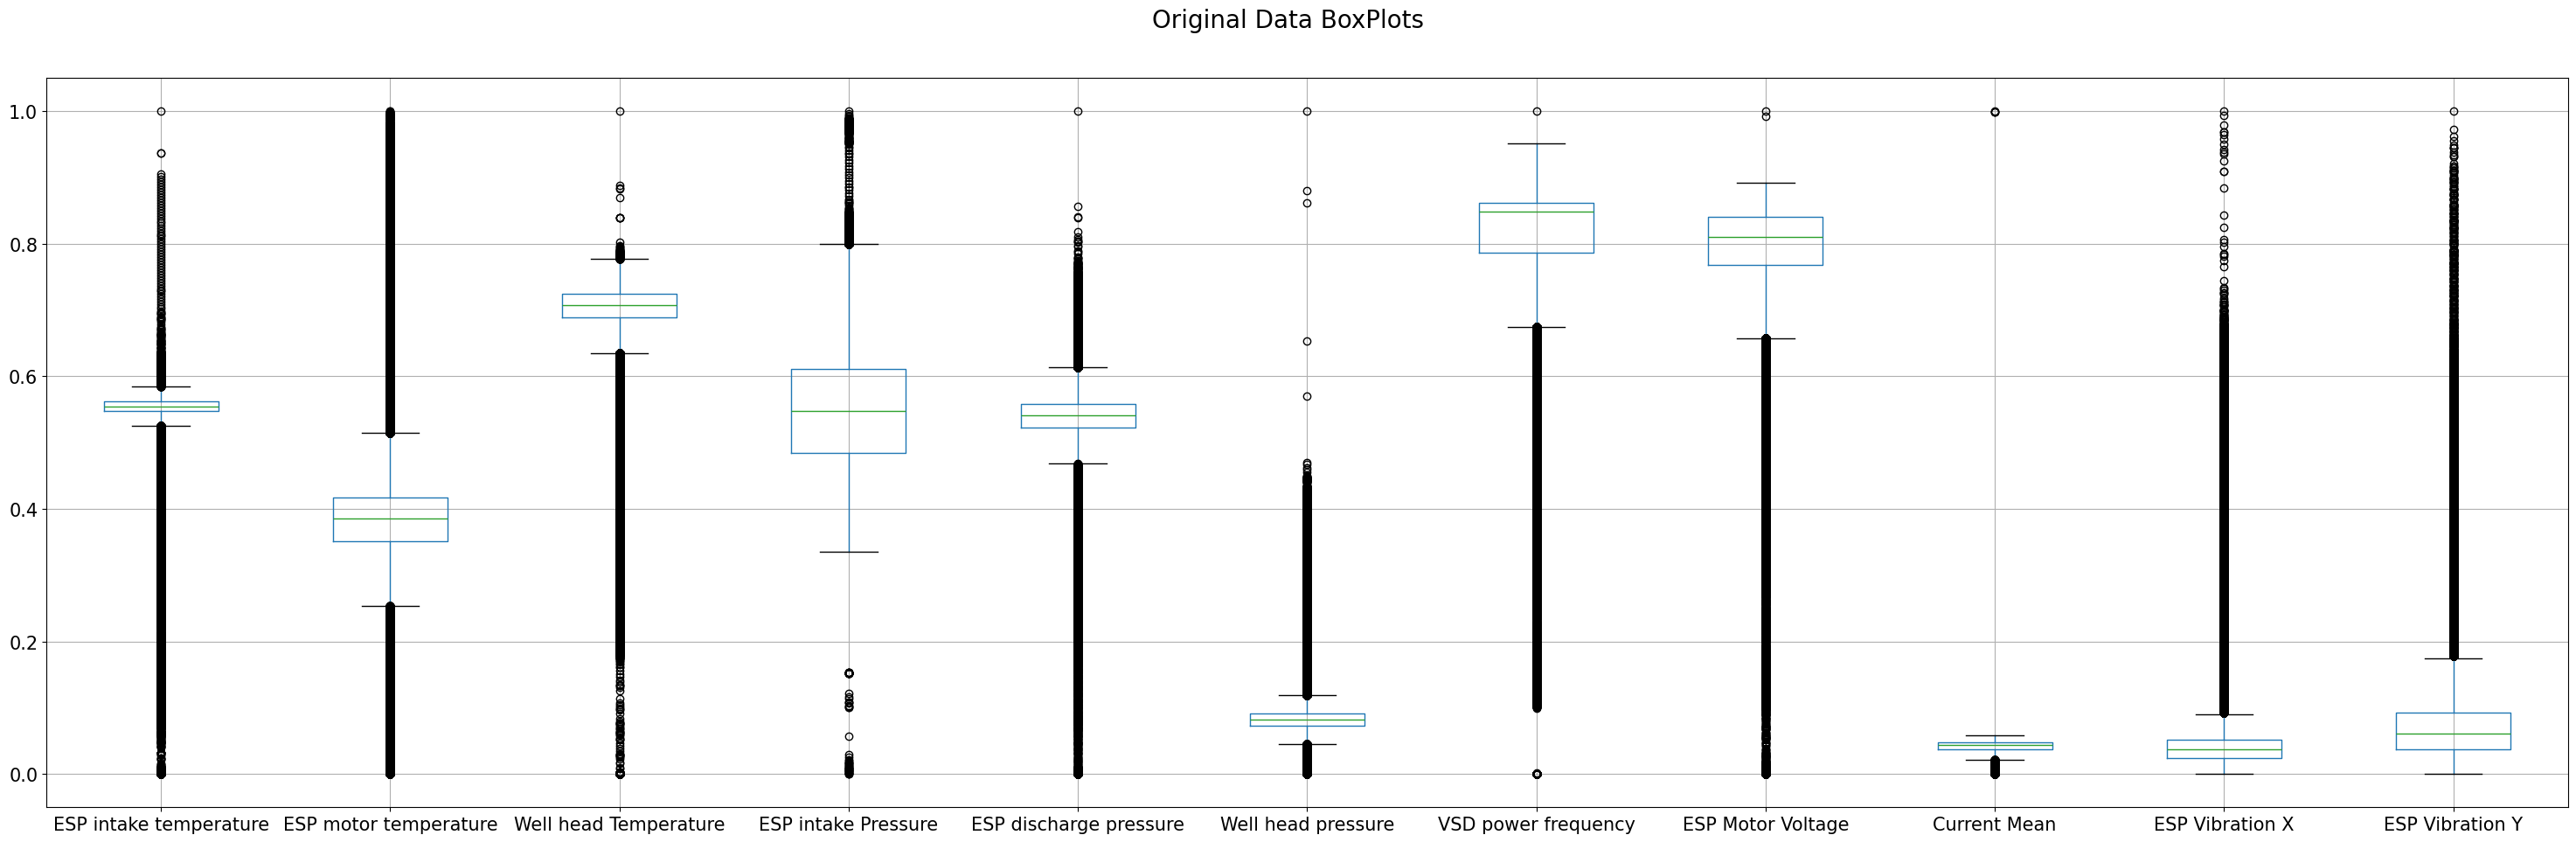

In [41]:
boxplot_data = entireData.loc[entireData["Well_down"]==0][Headers].copy().fillna(0)
#boxplot_data["ESP Motor Voltage"] = boxplot_data["ESP Motor Voltage"]/1000
pd.plotting.boxplot(((boxplot_data-boxplot_data.min())/(boxplot_data.max()-boxplot_data.min())),figsize=(30,10))


plt.rcParams["font.size"]=20
plt.suptitle("Original Data BoxPlots",fontsize=20)
plt.tight_layout(pad=1.3)
plt.savefig("../imagens_gerais/boxplot_original.jpg")

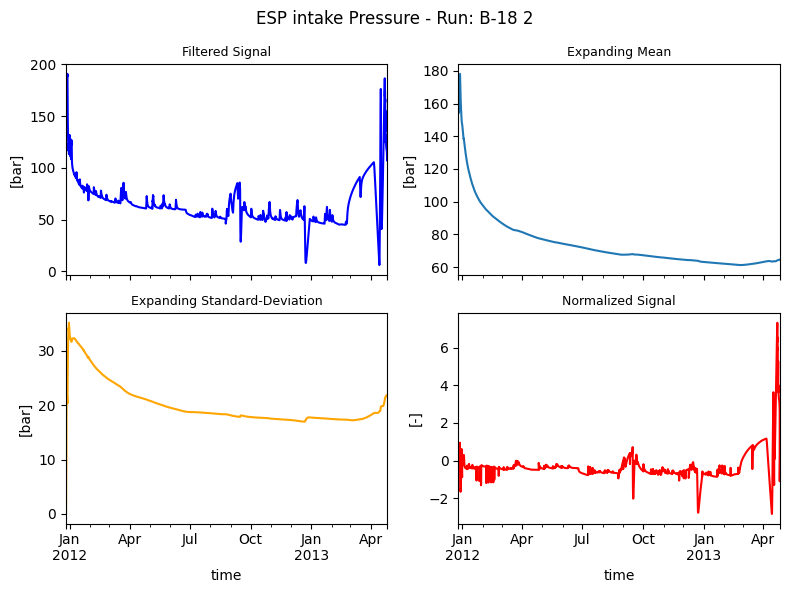

In [20]:
pump = pumpList[0]

pumpData = entireData.loc[entireData["Well Run"]==pump]
pumpTotalData = totalData.loc[totalData["Well Run"]==pump]

fig,axs = plt.subplots(2,2,figsize=(8,6),sharex=True)


pumpData["ESP intake Pressure"].ewm(span=24).mean().plot(ax=axs[0,0],color="blue")

pumpData["ESP intake Pressure"].expanding().mean().plot(ax=axs[0,1])
pumpData["ESP intake Pressure"].expanding().std().plot(ax=axs[1,0],color="orange")


pumpTotalData["ESP intake Pressure"].plot(ax=axs[1,1],color="red")



axs[0,0].set_xlabel("time")
axs[1,1].set_xlabel("time")

axs[0,0].set_ylabel("[bar]")
axs[0,1].set_ylabel("[bar]")
axs[1,0].set_ylabel("[bar]")
axs[1,1].set_ylabel("[-]")

axs[0,0].set_title("Filtered Signal",fontsize=9)
axs[0,1].set_title("Expanding Mean",fontsize=9)
axs[1,0].set_title("Expanding Standard-Deviation",fontsize=9)
axs[1,1].set_title("Normalized Signal",fontsize=9)
fig.suptitle("ESP intake Pressure - Run: " + pump)
plt.tight_layout()

plt.savefig("../imagens_gerais/z_score_formation.jpg")



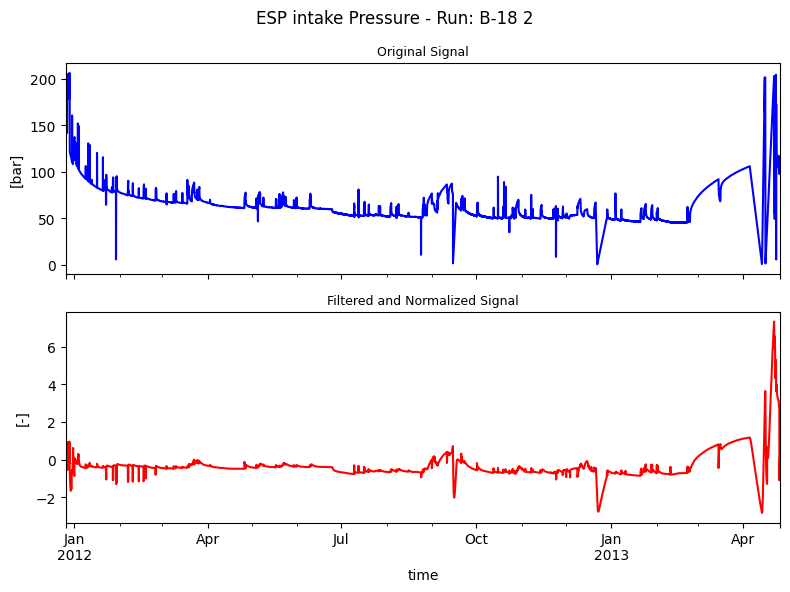

In [19]:
pump = pumpList[0]

pumpData = entireData.loc[entireData["Well Run"]==pump]
pumpTotalData = totalData.loc[totalData["Well Run"]==pump]

fig,axs = plt.subplots(2,1,figsize=(8,6),sharex=True)
pumpData["ESP intake Pressure"].plot(ax=axs[0],color="blue")
pumpTotalData["ESP intake Pressure"].plot(ax=axs[1],color="red")

axs[1].set_xlabel("time")
axs[0].set_ylabel("[bar]")
axs[1].set_ylabel("[-]")

axs[0].set_title("Original Signal",fontsize=9)
axs[1].set_title("Filtered and Normalized Signal",fontsize=9)
fig.suptitle("ESP intake Pressure - Run: " + pump)
plt.tight_layout()

plt.savefig("../imagens_gerais/pressao_b18_2.jpg")


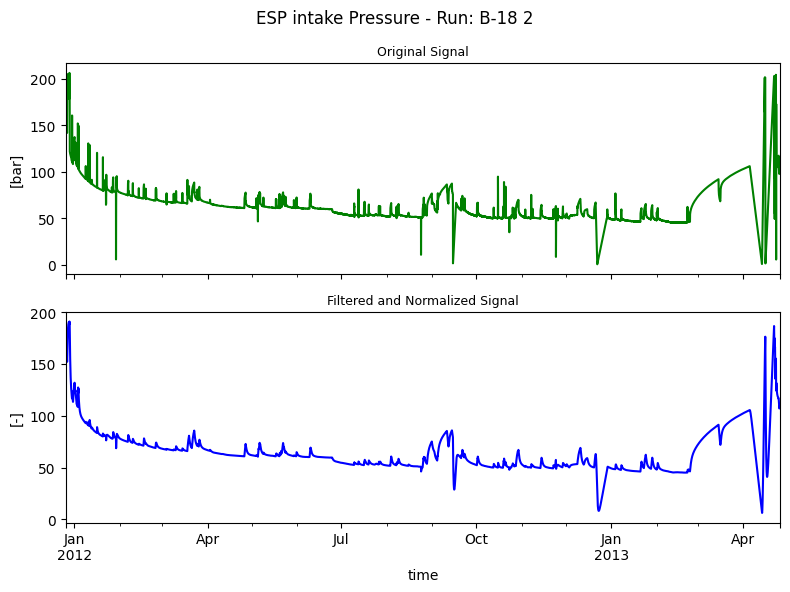

In [7]:
pump = pumpList[0]

pumpData = entireData.loc[entireData["Well Run"]==pump]

fig,axs = plt.subplots(2,1,figsize=(8,6),sharex=True)
pumpData["ESP intake Pressure"].plot(ax=axs[0],color="green")
pumpData["ESP intake Pressure"].ewm(span=24).mean().plot(ax=axs[1],color="blue")

axs[1].set_xlabel("time")
axs[0].set_ylabel("[bar]")
axs[1].set_ylabel("[-]")

axs[0].set_title("Original Signal",fontsize=9)
axs[1].set_title("Filtered and Normalized Signal",fontsize=9)
fig.suptitle("ESP intake Pressure - Run: " + pump)
plt.tight_layout()

plt.savefig("../imagens_gerais/pressao_b18_2.jpg")
